# 05 TimeGPT / Nixtla (MLForecast)\nThis notebook mirrors the XGBoost scope with a Nixtla-style pipeline using **MLForecast** and a **rolling daily backtest** (`h=24`).

### Introduction
The goal is to predict the energy price.
All exogenous factors are known for the next 24 hours, because every day at noon all the exogenours factors for the next day are published and will go into condiseration for the energy price bidding at noon which determines all prices for the next day (all 24 hours for hour 0-23). Only the gas price is an execption; this is the day price, but it should not matter too much in this case from one day to another, while predicted load or percentage of renewable engergies (res_sum_da) will be estimated  for the next day and might differ from the day before. 
So exogenous factors are only there for the next 24 hours, after that not. The only way would be to make a predition on them after 24 hours. So the simplest is to keep the prediction horizont for 24 hours only. 
Sesonality we see for each day, each week and also each year. 

### What it now does:

Mirrors your XGBoost data scope and split (2019-01-01 to 2025-12-31, test year 2025).
Uses MLForecast + XGBRegressor.
Keeps price_gas explicitly as an exogenous feature.
Runs a rolling daily backtest (h=24) to match your day-ahead setup.
Uses point forecasts only (no intervals).
Reports RMSE, MAE, MAPE and plots full-period + 7-day zoom.

### Extra Infos
2. One-shot holdout vs rolling daily backtest

One-shot holdout

Train once on historical data (e.g., up to 2024-12-31), then predict the full test period (e.g., all of 2025).
Simple and fast.
But it is less realistic for operations, because in reality you retrain/update over time and only forecast the next 24h each day.
Rolling daily backtest (recommended for your setup)

Simulate real operation day by day: at each day’s noon, use only information available then, forecast next 24 hours, move one day forward, repeat.
Gives more trustworthy performance for your bidding workflow.
More compute, but much better evaluation quality.
For your day-ahead energy market setup, rolling backtest is usually the better evaluation.

3. Point forecasts vs prediction intervals

Point forecast only

One value per hour (best estimate).
Example: hour 18 price = 92.4.
Good if you only need a single bid value.
Prediction intervals

A range plus uncertainty level.
Example: hour 18 = 92.4, 80% interval [84.1, 101.7], 95% interval [76.5, 109.8].
Useful for risk-aware bidding and understanding volatile hours.
If your bidding strategy cares about risk (not just average error), intervals are very valuable.

### Question to codex:
One moment: can you first verrify my understanding on your explanaition?
"""Rolling daily backtest (recommended for your setup)

Simulate real operation day by day: at each day’s noon, use only information available then, forecast next 24 hours, move one day forward, repeat.
Gives more trustworthy performance for your bidding workflow.
More compute, but much better evaluation quality."""
What does this mean for the test period exactly? Understand there are no estimation going in after the first 24 hours/data points predicted. For the 2nd cycle of estimations (25 to 48 hours) it orients it self on the actual data? 
Please correct if wrong.
Maybe you can describe step by step what is happening for the first 3 or 5 24 hour cycles?

### Answer:
Your understanding is very close. The key distinction is:

* In a rolling daily backtest, each 24h forecast block is made using data that would have been available at that day’s forecast time.
* For the next cycle, the model can use actual realized prices up to that new cutoff time (because in backtest, history is known).
So yes: for cycle 2 (hours 25-48), it orients on actual observed data up to that point, not on cycle-1 predictions (unless you intentionally design a recursive multi-day simulation).

##### Step-by-step (first 5 cycles, test starts at 2025-01-01 00 (line 0)):

Cycle 1 (cutoff around 2025-01-01 00 (line 0))
* Train on history < 2025-01-01 00 (line 0).
* Use exogenous known for 2025-01-01 00 (line 0) to 2025-01-01 23 (line 0).
* Predict those 24 prices.
* Compare with actuals for that day.

Cycle 2 (cutoff 2025-01-02 00 (line 0))
* Now history includes actual prices of Jan 1.
* Train/update using history < 2025-01-02 00 (line 0).
* Use exogenous for Jan 2 (24h).
* Predict Jan 2 hours 0-23.
* Compare with actuals.

Cycle 3 (cutoff 2025-01-03 00 (line 0))
* History includes actual Jan 1-2.
* Predict Jan 3 next 24h using Jan 3 exogenous.

Cycle 4 (cutoff 2025-01-04 00 (line 0))
* History includes actual Jan 1-3.
* Predict Jan 4 next 24h.

Cycle 5 (cutoff 2025-01-05 00 (line 0))
* History includes actual Jan 1-4.
* Predict Jan 5 next 24h.

##### Important:
* This is not “one long 8760-hour forecast” from Jan 1.
* It is many 24-hour forecasts, each re-anchored with newly available actuals.
* That is why it better matches daily market operations.

In [1]:
# If needed:
# %pip install mlforecast xgboost utilsforecast

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [2]:
# Config
DATA_PATH = '../../data_cleaned/merged/02_4_clean_data.csv'
TARGET = 'price'
H = 24

start_date = pd.Timestamp('2019-01-01 00:00:00')
split_date = pd.Timestamp('2025-01-01 00:00:00')
end_date = pd.Timestamp('2026-01-01 00:00:00')


In [3]:
# Load and align schema
df = pd.read_csv(DATA_PATH)

df['period_start_utc'] = pd.to_datetime(df['period_start_utc'], errors='coerce', utc=True).dt.tz_localize(None)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Mirror the XGBoost notebook: one-hot encode year and keep numeric features
df = pd.get_dummies(df, columns=['year'], drop_first=True)

# Keep only the project date range
df = df[(df['date'] >= start_date) & (df['date'] < end_date)].copy()

# Build Nixtla format
df = df.rename(columns={'period_start_utc': 'ds', TARGET: 'y'})
df['unique_id'] = 'de_price'

# Sort and reset index
df = df.sort_values(['unique_id', 'ds']).reset_index(drop=True)

print(df[['unique_id', 'ds', 'y']].head())
print(f'Rows: {len(df):,} | Range: {df.ds.min()} -> {df.ds.max()}')


  unique_id                  ds      y
0  de_price 2019-01-01 00:00:00  10.07
1  de_price 2019-01-01 01:00:00  -4.08
2  de_price 2019-01-01 02:00:00  -9.91
3  de_price 2019-01-01 03:00:00  -7.41
4  de_price 2019-01-01 04:00:00 -12.55
Rows: 61,367 | Range: 2019-01-01 00:00:00 -> 2025-12-31 22:00:00


In [4]:
# Feature scope from XGBoost + keep price_gas
base_exog = [
    'load_forecast_da', 'res_sum_da', 'gen_forecast_da',
    'dayofyear_sin1', 'dayofyear_cos1',
    'hour_sin1', 'hour_cos1',
    'dayofweek_sin1', 'dayofweek_cos1',
    'is_holiday', 'price_gas'
]
year_dummies = [c for c in df.columns if c.startswith('year_')]
exog_cols = base_exog + year_dummies

missing = [c for c in exog_cols + ['y', 'ds', 'unique_id'] if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

model_df = df[['unique_id', 'ds', 'y'] + exog_cols].copy()

train_mask = model_df['ds'] < split_date
test_mask = (model_df['ds'] >= split_date) & (model_df['ds'] < end_date)

print(f'Train rows: {train_mask.sum():,}')
print(f'Test rows:  {test_mask.sum():,}')
print(f'Exogenous features ({len(exog_cols)}): {exog_cols}')


Train rows: 52,608
Test rows:  8,759
Exogenous features (17): ['load_forecast_da', 'res_sum_da', 'gen_forecast_da', 'dayofyear_sin1', 'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1', 'dayofweek_cos1', 'is_holiday', 'price_gas', 'year_2020', 'year_2021', 'year_2022', 'year_2023', 'year_2024', 'year_2025']


In [5]:
# Rolling daily backtest setup
# At each day, train on history up to that day and forecast next 24h with known day-ahead exogenous values.

cutoffs = pd.date_range(start=split_date, end=end_date - pd.Timedelta(days=1), freq='D')
print(f'Backtest windows: {len(cutoffs)} days')


Backtest windows: 365 days


In [6]:
# Model definition
# Lags chosen for day-ahead logic: 24h and 168h (no lag-1).

xgb = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

fcst = MLForecast(
    models={'xgb': xgb},
    freq='H',
    lags=[24, 168],
    lag_transforms={
        24: [RollingMean(window_size=24)],
        168: [RollingMean(window_size=24)]
    },
    date_features=['hour', 'dayofweek', 'month', 'dayofyear']
)


In [7]:
# Rolling fit-predict loop
preds = []

for i, cutoff in enumerate(cutoffs, 1):
    train_df = model_df[model_df['ds'] < cutoff][['unique_id', 'ds', 'y'] + exog_cols]
    horizon_end = cutoff + pd.Timedelta(hours=H)

    future_exog = model_df[(model_df['ds'] >= cutoff) & (model_df['ds'] < horizon_end)][['unique_id', 'ds'] + exog_cols]

    # Skip incomplete windows (safety guard)
    if len(future_exog) != H:
        continue

    fcst.fit(train_df, static_features=[])
    pred = fcst.predict(h=H, X_df=future_exog)
    pred['cutoff'] = cutoff
    preds.append(pred)

    if i % 30 == 0:
        print(f'Processed {i}/{len(cutoffs)} windows')

preds_df = pd.concat(preds, ignore_index=True)
preds_df.head()


Processed 30/365 windows
Processed 60/365 windows
Processed 90/365 windows
Processed 120/365 windows
Processed 150/365 windows
Processed 180/365 windows
Processed 210/365 windows
Processed 240/365 windows
Processed 270/365 windows
Processed 300/365 windows
Processed 330/365 windows
Processed 360/365 windows


,unique_id,ds,xgb,cutoff
0,de_price,2025-01-01 00:00:00,-6.200180,2025-01-01
1,de_price,2025-01-01 01:00:00,-7.535347,2025-01-01
2,de_price,2025-01-01 02:00:00,-5.695451,2025-01-01
3,de_price,2025-01-01 03:00:00,-3.615350,2025-01-01
4,de_price,2025-01-01 04:00:00,-6.869017,2025-01-01


In [8]:
# Join predictions with actuals
actuals = model_df[['unique_id', 'ds', 'y']].copy()
res = preds_df.merge(actuals, on=['unique_id', 'ds'], how='left')
res = res.rename(columns={'xgb': 'prediction', 'y': 'actual'})

res.head()


,unique_id,ds,prediction,cutoff,actual
0,de_price,2025-01-01 00:00:00,-6.200180,2025-01-01,1.60
1,de_price,2025-01-01 01:00:00,-7.535347,2025-01-01,0.00
2,de_price,2025-01-01 02:00:00,-5.695451,2025-01-01,-0.01
3,de_price,2025-01-01 03:00:00,-3.615350,2025-01-01,-0.01
4,de_price,2025-01-01 04:00:00,-6.869017,2025-01-01,-0.06


In [9]:
# Metrics (point forecast only)
rmse = mean_squared_error(res['actual'], res['prediction'], squared=False)
mae = mean_absolute_error(res['actual'], res['prediction'])

# Guard MAPE against zeros
eps = 1e-8
mape = np.mean(np.abs((res['actual'] - res['prediction']) / np.maximum(np.abs(res['actual']), eps))) * 100

print(f'RMSE: {rmse:,.4f}')
print(f'MAE:  {mae:,.4f}')
print(f'MAPE: {mape:,.2f}%')


RMSE: 20.2841
MAE:  12.5253
MAPE: 1,044,979,040.58%


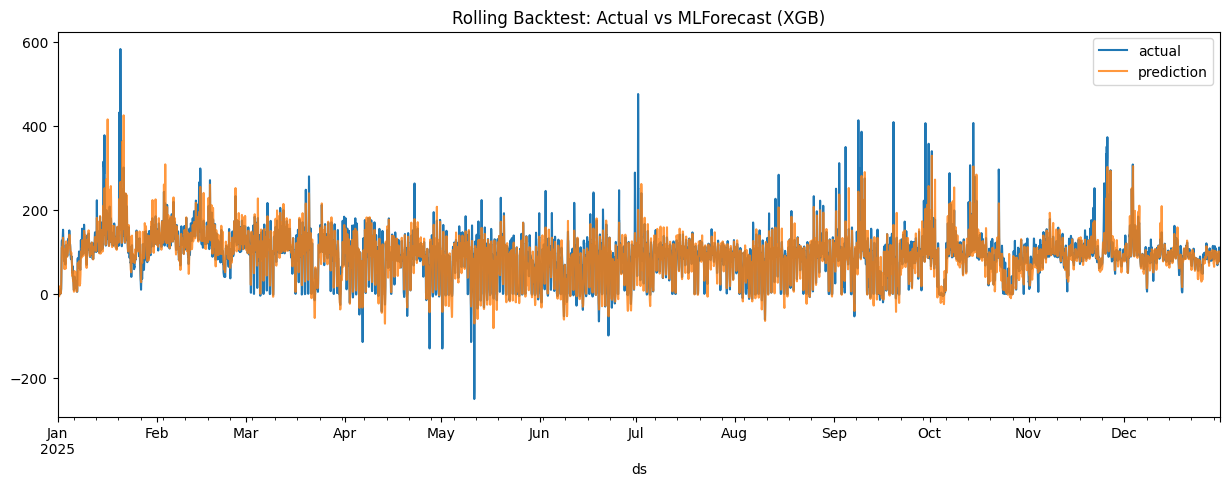

In [10]:
# Plot full test period
plot_df = res.set_index('ds').sort_index()

ax = plot_df[['actual']].plot(figsize=(15, 5), title='Rolling Backtest: Actual vs MLForecast (XGB)')
plot_df['prediction'].plot(ax=ax, alpha=0.8)
ax.legend(['actual', 'prediction'])
plt.show()


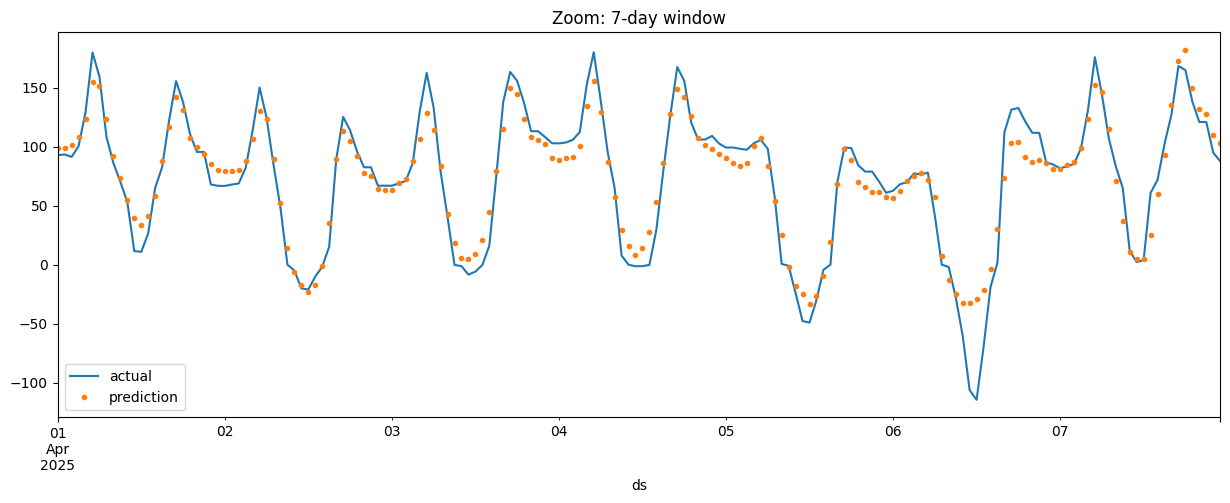

In [11]:
# Zoom into one representative week
zoom_start = split_date + pd.Timedelta(days=90)
zoom_end = zoom_start + pd.Timedelta(days=7)

zoom = plot_df[(plot_df.index >= zoom_start) & (plot_df.index < zoom_end)]
ax = zoom[['actual']].plot(figsize=(15, 5), title='Zoom: 7-day window')
zoom['prediction'].plot(ax=ax, style='.')
ax.legend(['actual', 'prediction'])
plt.show()


## Notes
- This notebook is **MLForecast-first** for controllable feature engineering and rolling evaluation.
- `price_gas` is intentionally retained as an important exogenous feature from your EDA findings.
- If you want, a later section can add a TimeGPT benchmark on the same `h=24` windows.

In [ ]:
# Unified metrics + export for comparison
from pathlib import Path

# normalize evaluation frame name
if 'results' in locals():
    eval_df = results.copy()
elif 'res' in locals():
    eval_df = res.copy()
else:
    raise ValueError('No results dataframe found (expected `results` or `res`).')

# normalize column names
if 'y' in eval_df.columns and 'actual' not in eval_df.columns:
    eval_df = eval_df.rename(columns={'y': 'actual'})
if 'xgb' in eval_df.columns and 'prediction' not in eval_df.columns:
    eval_df = eval_df.rename(columns={'xgb': 'prediction'})
if 'ds' not in eval_df.columns and eval_df.index.name is not None:
    eval_df = eval_df.reset_index()

required_cols = {'actual', 'prediction'}
missing = required_cols - set(eval_df.columns)
if missing:
    raise ValueError(f'Missing required columns for metrics/export: {missing}')

# robust metrics for power prices (can be near zero/negative)
rmse = mean_squared_error(eval_df['actual'], eval_df['prediction'], squared=False)
mae = mean_absolute_error(eval_df['actual'], eval_df['prediction'])
smape = 100 * np.mean(
    2 * np.abs(eval_df['actual'] - eval_df['prediction']) /
    (np.abs(eval_df['actual']) + np.abs(eval_df['prediction']) + 1e-8)
)

mask = np.abs(eval_df['actual']) >= 10
mape_filtered = (
    np.mean(
        np.abs((eval_df.loc[mask, 'actual'] - eval_df.loc[mask, 'prediction']) /
               np.abs(eval_df.loc[mask, 'actual']))
    ) * 100
    if mask.any() else np.nan
)

print(f'RMSE: {rmse:,.4f}')
print(f'MAE:  {mae:,.4f}')
print(f'sMAPE: {smape:,.2f}%')
print(f'MAPE (|actual|>=10): {mape_filtered:,.2f}%')

out_dir = Path('../../artifacts/model_results')
out_dir.mkdir(parents=True, exist_ok=True)

metrics_df = pd.DataFrame([{
    'model': 'MLForecast_XGB',
    'rmse': rmse,
    'mae': mae,
    'smape': smape,
    'mape_filtered_abs_ge_10': mape_filtered,
    'n_predictions': len(eval_df)
}])

metrics_df.to_csv(out_dir / 'mlforecast_xgb_metrics_rolling_24h.csv', index=False)

pred_cols = [c for c in ['unique_id', 'cutoff', 'ds', 'actual', 'prediction'] if c in eval_df.columns]
eval_df[pred_cols].to_csv(out_dir / 'mlforecast_xgb_predictions_rolling_24h.csv', index=False)

metrics_df
